<a href="https://colab.research.google.com/github/sathana495/ML-project/blob/main/daibetes_prediction2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Daibetes prediction

*step 1 : Data uploading*

In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/dataset/diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
df.isna().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


*step 2 : ensure the dataset are preprocesses or not*

*step 3 : Data visulaization for batter understanding*

In [ ]:
core=df.corr()


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

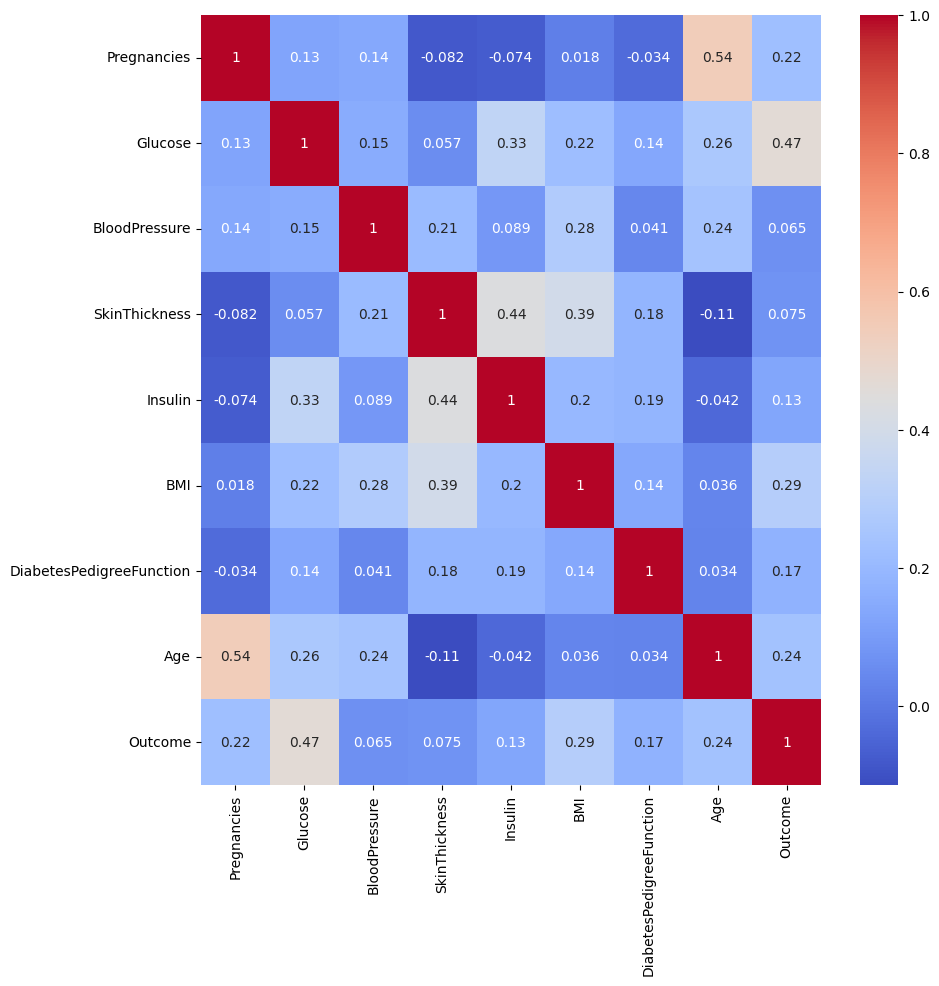

In [ ]:
plt.figure(figsize=(10,10))
sns.heatmap(core,annot=True,cmap='coolwarm')
plt.show()

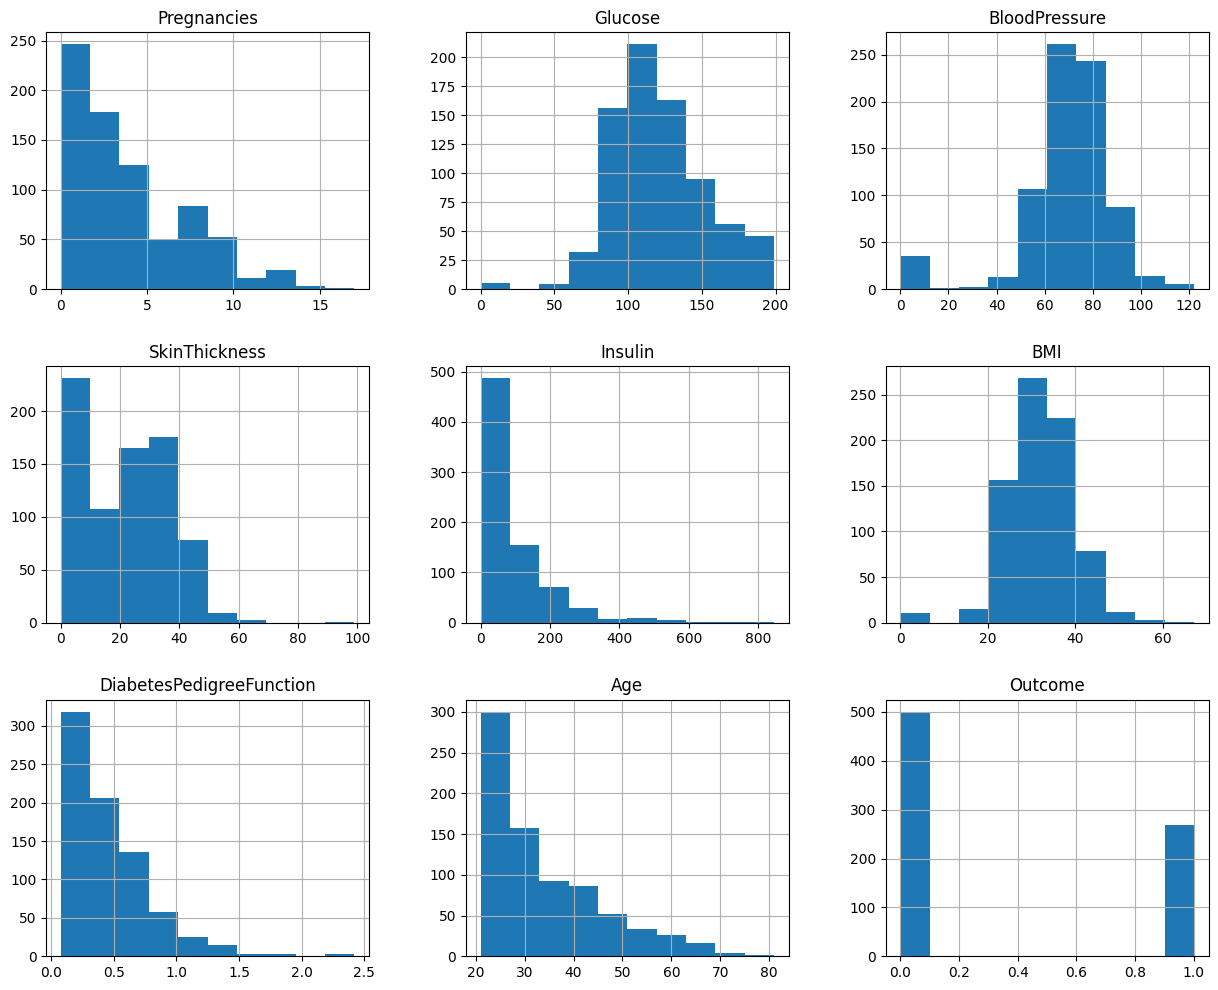

In [ ]:
df.hist(figsize=(15,12))
plt.show()

*step 4 : split the train & test data*

In [ ]:
x = df.drop('Outcome',axis=1)
y = df['Outcome']



In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
x

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63
764,2,122,70,27,0,36.8,0.340,27
765,5,121,72,23,112,26.2,0.245,30
766,1,126,60,0,0,30.1,0.349,47


In [ ]:
y

,Outcome
0,1
1,0
2,1
3,0
4,1
...,...
763,0
764,0
765,0
766,1


*step 6 : build a logistic model for daibetes prediction*

In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
y_pred = model.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [ ]:
model_accuracy = accuracy_score(y_test,y_pred)
model_accuracy

0.7402597402597403

In [ ]:
model_classification = classification_report(y_test,y_pred)
print(model_classification)


              precision    recall  f1-score   support

           0       0.80      0.79      0.80        99
           1       0.63      0.65      0.64        55

    accuracy                           0.74       154
   macro avg       0.72      0.72      0.72       154
weighted avg       0.74      0.74      0.74       154



In [ ]:
model_confusion = confusion_matrix(y_test,y_pred)
print(model_confusion)

[[78 21]
 [19 36]]


### Predict for a new individual
Let's test the model with some sample data for a new individual. You can modify these values to predict for different scenarios.

In [ ]:
import pandas as pd

# Sample data for a new individual (replace with actual values)
# Ensure the order of features matches the training data (x)
new_person_data = {
    'Pregnancies': [2],
    'Glucose': [130],
    'BloodPressure': [70],
    'SkinThickness': [30],
    'Insulin': [120],
    'BMI': [35.0],
    'DiabetesPedigreeFunction': [0.4],
    'Age': [30]
}

# Create a DataFrame from the sample data
new_person_df = pd.DataFrame(new_person_data)

# Make a prediction
prediction = model.predict(new_person_df)

# Display the prediction
if prediction[0] == 1:
    print("The model predicts: This person is likely to have diabetes.")
else:
    print("The model predicts: This person is likely NOT to have diabetes.")


The model predicts: This person is likely NOT to have diabetes.


*step 7 : bulid a random forest model*

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model2 = RandomForestClassifier()

In [ ]:
model2.fit(x_train,y_train)

RandomForestClassifier()

In [ ]:
y_pred = model2.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [ ]:
model2_accuracy = accuracy_score(y_test,y_pred)
model2_accuracy

0.7532467532467533

*step 8 : build a RandomizedSearchCV model*

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb

# Define the parameter distribution for RandomizedSearchCV for XGBoost
param_dist_xgb = {
    'n_estimators': [100, 200, 300, 400, 500, 600],  # Number of boosting rounds
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],  # Step size shrinkage to prevent overfitting
    'max_depth': [3, 5, 7, 9, 11],  # Maximum depth of a tree
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],  # Subsample ratio of the training instance
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],  # Subsample ratio of columns when constructing each tree
    'gamma': [0, 0.1, 0.2, 0.3, 0.4],  # Minimum loss reduction required to make a further partition on a leaf node
    'reg_alpha': [0, 0.001, 0.005, 0.01, 0.05, 0.1], # L1 regularization term on weights
    'reg_lambda': [1, 0.5, 0.1, 0.05, 0.01] # L2 regularization term on weights
}

# Create an XGBoost Classifier model
# Ensure `use_label_encoder=False` and `eval_metric='logloss'` for compatibility if not using latest XGBoost version
xgb_base = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=42)

# Instantiate the RandomizedSearchCV object
# n_iter: Number of parameter settings that are sampled. More iterations means a more exhaustive search.
# cv: Determines the cross-validation splitting strategy.
# n_jobs=-1 uses all available cores for parallel processing
random_search_xgb = RandomizedSearchCV(estimator=xgb_base, param_distributions=param_dist_xgb,
                                       n_iter=50, cv=5, verbose=2, random_state=42, n_jobs=-1)

# Fit the random search model to the scaled training data
# This step might take some time to run.
print("Starting XGBoost hyperparameter tuning...")
random_search_xgb.fit(x_train_scaled, y_train)
print("XGBoost hyperparameter tuning complete.")

# Get the best parameters and best score
best_params_xgb = random_search_xgb.best_params_
best_score_xgb = random_search_xgb.best_score_

print(f"\nBest XGBoost Parameters found: {best_params_xgb}")
print(f"Best Cross-validation score for XGBoost: {best_score_xgb:.4f}")

Starting XGBoost hyperparameter tuning...
Fitting 5 folds for each of 50 candidates, totalling 250 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:30:49] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost hyperparameter tuning complete.

Best XGBoost Parameters found: {'subsample': 1.0, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 600, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 1.0}
Best Cross-validation score for XGBoost: 0.7835
